In [ ]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample

### Plot Styles

In [2]:
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({"figure.dpi": 120})

### Load Data Path

In [ ]:
EXTRACTED_DIR = Path("../Extracted_data")          
LOG_CSV       = Path("../extraction_log.csv")        
CLEAN_CSV     = Path("../dataset_clean.csv")        # output: cleaned, original dist -> fairness/SHAP
OUTPUT_CSV    = Path("../dataset_balanced.csv")     # output: resampled -> DistilBERT training

### Fix UTF-8

In [4]:
import ftfy

# Apply ftfy to all .txt files before cleaning
fixed_count = 0
for txt_file in sorted(EXTRACTED_DIR.glob("**/*.txt")):
    raw   = txt_file.read_text(encoding="utf-8", errors="replace")
    fixed = ftfy.fix_text(raw)
    if fixed != raw:
        txt_file.write_text(fixed, encoding="utf-8")
        fixed_count += 1

print(f"ftfy applied (v)")
print(f"Files with encoding artifacts fixed: {fixed_count}")

# Quick sanity check — show before/after on a sample
sample = 'Responsbilityâ€¢ Maintain Â· clean Â§ safe'
print(f"\nBefore: {sample}")
print(f"After : {ftfy.fix_text(sample)}")


ftfy applied (v)
Files with encoding artifacts fixed: 1015

Before: Responsbilityâ€¢ Maintain Â· clean Â§ safe
After : Responsbility• Maintain · clean § safe


### Text Cleaning & PII Removal

In [18]:
# PII patterns 
_PHONE   = re.compile(r"(?:\+?1[\s\-.])?" r"(?:\(?\d{3}\)?[\s\-.])" r"\d{3}[\s\-.]?\d{4}")
_EMAIL   = re.compile(r"[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+")
_URL     = re.compile(
    r"(?:https?://|www\.)"
    r"(?:linkedin\.com|github\.com|twitter\.com|facebook\.com|instagram\.com)"
    r"[^\s]*",
    re.IGNORECASE
)
_ADDRESS = re.compile(
    r"\d{1,5}\s+(?:[A-Z][a-z]+\s+){1,4}"
    r"(?:St|Ave|Rd|Blvd|Dr|Ln|Way|Court|Ct|Place|Pl|Suite|Ste)\.?",
    re.IGNORECASE
)
_NAME_TOP = re.compile(r"^(?:[A-Z][a-z]+\s+){1,3}[A-Z][a-z]+")
_PHOTO    = re.compile(r"(?:profile\s*photo|photo\.(?:jpg|jpeg|png|gif))", re.IGNORECASE)
_PAGE_TAG = re.compile(r"---\s*Page\s*\d+(?:\s*\(OCR\))?\s*---")

# Noise symbols (after ftfy, non-alphanumeric except kept chars) 
# Keep: letters, digits, whitespace, hyphen (compound words), period (abbreviations), comma, @ (for PII regex to catch email first)
_SYMBOLS  = re.compile(r"[^a-zA-Z0-9\s\-\.,@]")


def clean_resume(text: str) -> str:
    # 1. Remove page markers
    text = _PAGE_TAG.sub(" ", text)

    # 2. Strip PII
    text = _NAME_TOP.sub("[NAME]", text, count=1)
    text = _PHONE.sub("[PHONE]", text)
    text = _EMAIL.sub("[EMAIL]", text)
    text = _URL.sub("[SOCIAL]", text)
    text = _ADDRESS.sub("[ADDRESS]", text)
    text = _PHOTO.sub("[PHOTO]", text)

    # 3. Remove noise symbols (•, ·, §, –, €, ©, etc.)
    text = _SYMBOLS.sub(" ", text)

    # 4. Collapse whitespace (tabs, newlines -> single space)
    text = re.sub(r"[\t\r\n]+", " ", text)
    text = re.sub(r" {2,}", " ", text)

    # 5. Lowercase
    return text.lower().strip()

# Sanity check
print("\nSymbol removal test:")
test = "Responsibilities: â€¢ Maintain Â· clean Â§ safe – organized workspace"
test_fixed = ftfy.fix_text(test)
print(f"  raw   : {test}")
print(f"  ftfy  : {test_fixed}")
print(f"  clean : {clean_resume(test_fixed)}")

print("\nSample output (300 chars):")
sample_path = next(EXTRACTED_DIR.glob("**/*.txt"))
raw = sample_path.read_text(encoding="utf-8")
print(clean_resume(raw)[:300])



Symbol removal test:
  raw   : Responsibilities: â€¢ Maintain Â· clean Â§ safe – organized workspace
  ftfy  : Responsibilities: • Maintain · clean § safe – organized workspace
  clean : responsibilities maintain clean safe organized workspace

Sample output (300 chars):
accountant summary financial accountant specializing in financial planning, reporting and analysis within the department of defense. highlights account reconciliations results-oriented accounting operations professional financial reporting analysis of financial systems critical thinking erp enterpri


In [19]:
cleaning_report = []

for txt_file in sorted(EXTRACTED_DIR.glob("**/*.txt")):
    raw     = txt_file.read_text(encoding="utf-8")
    cleaned = clean_resume(raw)

    wc_before = len(raw.split())
    wc_after  = len(cleaned.split())

    txt_file.write_text(cleaned, encoding="utf-8")

    pii_tags = ["[phone]", "[email]", "[social]", "[address]", "[name]"]
    cleaning_report.append({
        "occupation": txt_file.parent.name,
        "filename":   txt_file.name,
        "wc_before":  wc_before,
        "wc_after":   wc_after,
        "pii_found":  any(tag in cleaned for tag in pii_tags),
    })

clean_report_df = pd.DataFrame(cleaning_report)
print(f"Files cleaned  : {len(clean_report_df)}")
print(f"PII detected   : {clean_report_df['pii_found'].sum()} file(s)")
print(f"Avg words before : {clean_report_df['wc_before'].mean():.0f}")
print(f"Avg words after  : {clean_report_df['wc_after'].mean():.0f}")


Files cleaned  : 2482
PII detected   : 0 file(s)
Avg words before : 808
Avg words after  : 813


In [20]:
# Reload df from cleaned .txt files
records = []
for occ_dir in sorted(EXTRACTED_DIR.iterdir()):
    if not occ_dir.is_dir():
        continue
    for txt_file in sorted(occ_dir.glob("*.txt")):
        text = txt_file.read_text(encoding="utf-8")
        records.append({
            "occupation": occ_dir.name,
            "filename":   txt_file.name,
            "text":       text,
            "char_count": len(text),
            "word_count": len(text.split()),
        })

df = pd.DataFrame(records)
df["tokens"]     = df["text"].apply(lambda t: re.findall(r"\b[a-z]{3,}\b", t))
df["vocab_size"] = df["tokens"].apply(lambda t: len(set(t)))

print(f"df reloaded: {len(df)} resumes")
print(df[["occupation", "filename", "word_count", "vocab_size"]].head(8))


df reloaded: 2482 resumes
   occupation      filename  word_count  vocab_size
0  ACCOUNTANT  10554236.txt        3500         916
1  ACCOUNTANT  10674770.txt        1042         412
2  ACCOUNTANT  11163645.txt         629         260
3  ACCOUNTANT  11759079.txt         853         367
4  ACCOUNTANT  12065211.txt         793         368
5  ACCOUNTANT  12202337.txt         753         314
6  ACCOUNTANT  12338274.txt         812         271
7  ACCOUNTANT  12442909.txt         645         313


In [21]:
# Save cleaned dataset (original distribution, no resampling)
# Used for fairness metrics & SHAP - reflects real-world class distribution
cols = ["occupation", "filename", "text", "word_count", "char_count", "vocab_size"]
df[cols].to_csv(CLEAN_CSV, index=False)

print(f"Saved : {CLEAN_CSV}")
print(f"Shape : {df.shape}")
print(f"\nClass distribution (original):")
print(df["occupation"].value_counts().to_string())
print("\n-> Used for fairness metrics & SHAP - reflects real-world class distribution")



Saved : ..\dataset_clean.csv
Shape : (2482, 7)

Class distribution (original):
occupation
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      119
ACCOUNTANT                118
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
FINANCE                   118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
CONSULTANT                115
HEALTHCARE                115
CONSTRUCTION              112
HR                        110
PUBLIC-RELATIONS          110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22

-> Used for fairness metrics & SHAP - reflects real-world class distribution


## 9. Class Imbalance Analysis & Handling

Strategy based on imbalance ratio:
- **< 3×** → minor, use `class_weight='balanced'` in model only
- **3–10×** → moderate, oversample minority + class weights
- **> 10×** → severe, oversample + undersample + class weights

Majority class : INFORMATION-TECHNOLOGY (120)
Minority class : BPO (22)
Imbalance ratio: 5.45x
Verdict: Moderate imbalance — oversample minority + class weights


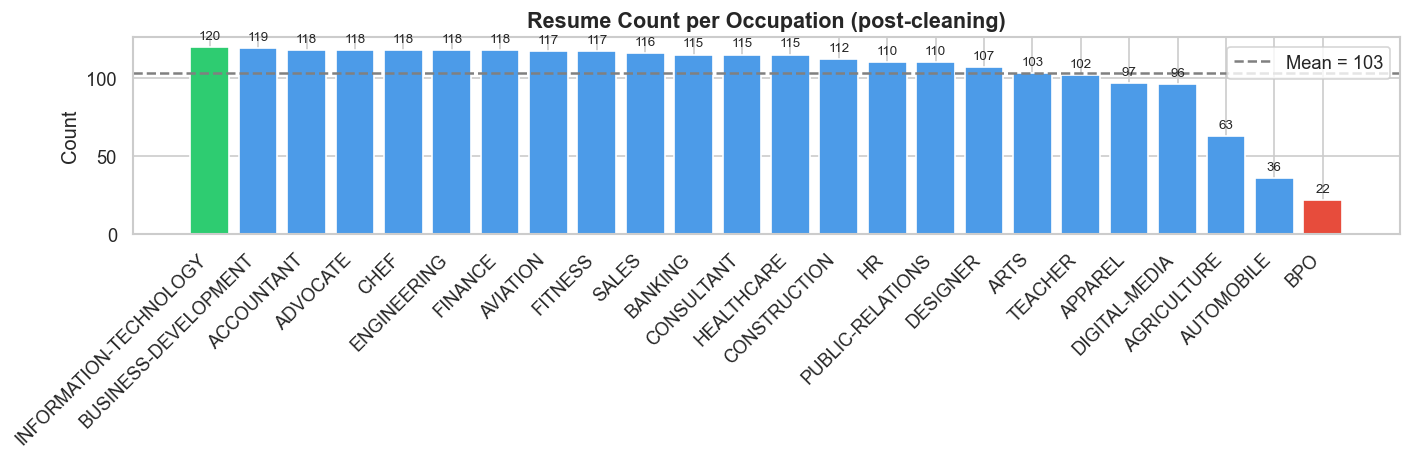

In [22]:
occ_counts = df["occupation"].value_counts().reset_index()
occ_counts.columns = ["occupation", "count"]

majority = occ_counts["count"].max()
minority = occ_counts["count"].min()
ratio    = majority / minority

print(f"Majority class : {occ_counts.iloc[0]['occupation']} ({majority})")
print(f"Minority class : {occ_counts.iloc[-1]['occupation']} ({minority})")
print(f"Imbalance ratio: {ratio:.2f}x")

if ratio < 3:
    verdict = "Minor imbalance — class_weight='balanced' sufficient"
elif ratio < 10:
    verdict = "Moderate imbalance — oversample minority + class weights"
else:
    verdict = "Severe imbalance — oversample + undersample + class weights"
print(f"Verdict: {verdict}")

fig, ax = plt.subplots(figsize=(12, 4))
colors = [
    "#e74c3c" if c == minority else
    "#2ecc71" if c == majority else
    "#4C9BE8"
    for c in occ_counts["count"]
]
bars = ax.bar(occ_counts["occupation"], occ_counts["count"], color=colors)
ax.bar_label(bars, padding=3, fontsize=8)
ax.axhline(occ_counts["count"].mean(), color="gray", linestyle="--",
           label=f"Mean = {occ_counts['count'].mean():.0f}")
ax.set_title("Resume Count per Occupation (post-cleaning)", fontsize=13, fontweight="bold")
ax.set_ylabel("Count")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [15]:
TARGET_N = int(occ_counts["count"].median())
print(f"Target count per class (median): {TARGET_N}\n")

balanced_dfs = []

for occ in df["occupation"].unique():
    occ_df = df[df["occupation"] == occ]
    n      = len(occ_df)

    if n < TARGET_N:
        resampled = resample(occ_df, replace=True,
                             n_samples=TARGET_N, random_state=42)
        tag = f"oversampled  {n:>3} → {TARGET_N}"
    elif n > TARGET_N:
        resampled = resample(occ_df, replace=False,
                             n_samples=TARGET_N, random_state=42)
        tag = f"undersampled {n:>3} → {TARGET_N}"
    else:
        resampled = occ_df
        tag = f"unchanged    {n:>3}"

    balanced_dfs.append(resampled)
    print(f"  {occ:<25} {tag}")

df_balanced = pd.concat(balanced_dfs).reset_index(drop=True)
print(f"\nBalanced df: {df_balanced.shape[0]} rows x {df_balanced.shape[1]} cols")


Target count per class (median): 115

  ACCOUNTANT                undersampled 118 → 115
  ADVOCATE                  undersampled 118 → 115
  AGRICULTURE               oversampled   63 → 115
  APPAREL                   oversampled   97 → 115
  ARTS                      oversampled  103 → 115
  AUTOMOBILE                oversampled   36 → 115
  AVIATION                  undersampled 117 → 115
  BANKING                   unchanged    115
  BPO                       oversampled   22 → 115
  BUSINESS-DEVELOPMENT      undersampled 119 → 115
  CHEF                      undersampled 118 → 115
  CONSTRUCTION              oversampled  112 → 115
  CONSULTANT                unchanged    115
  DESIGNER                  oversampled  107 → 115
  DIGITAL-MEDIA             oversampled   96 → 115
  ENGINEERING               undersampled 118 → 115
  FINANCE                   undersampled 118 → 115
  FITNESS                   undersampled 117 → 115
  HEALTHCARE                unchanged    115
  HR       

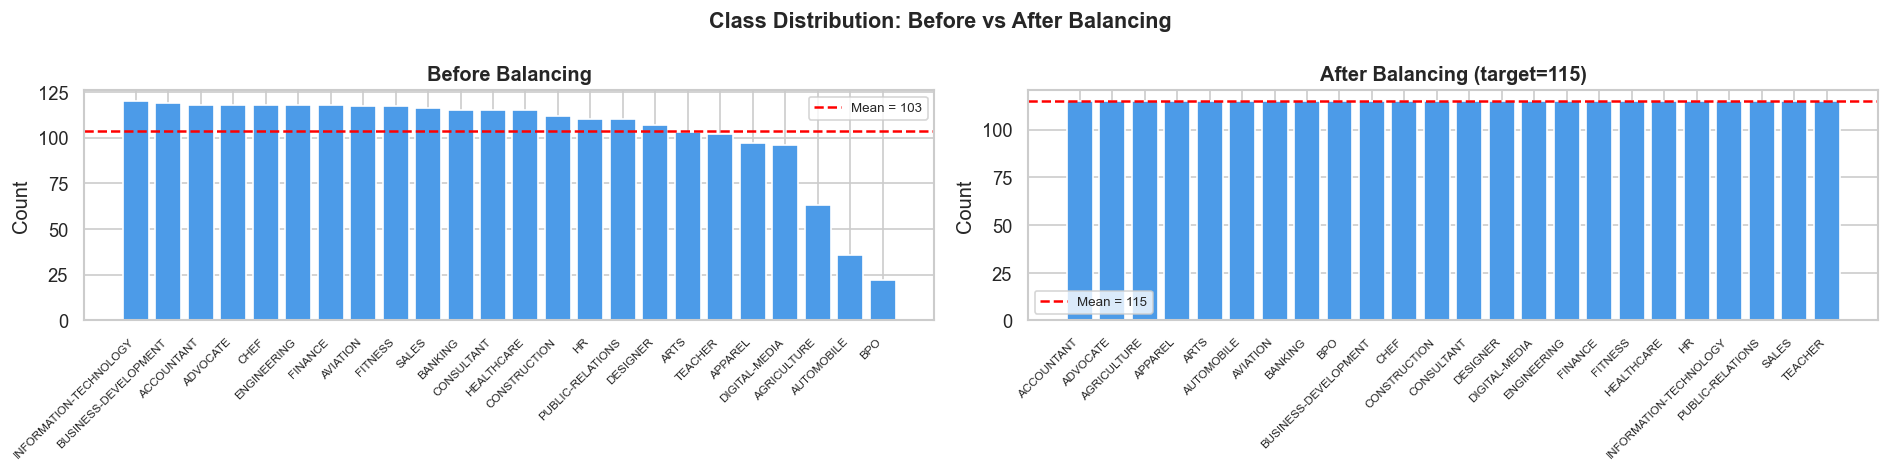


df          : 2482 resumes (original cleaned)
df_balanced : 2760 resumes (ready for DistilBERT)


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

for ax, data, title in zip(
    axes,
    [df, df_balanced],
    ["Before Balancing", f"After Balancing (target={TARGET_N})"]
):
    counts = data["occupation"].value_counts()
    ax.bar(counts.index, counts.values, color="#4C9BE8", edgecolor="white")
    ax.axhline(counts.mean(), color="red", linestyle="--",
               label=f"Mean = {counts.mean():.0f}")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=7)

plt.suptitle("Class Distribution: Before vs After Balancing", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\ndf          : {len(df)} resumes (original cleaned)")
print(f"df_balanced : {len(df_balanced)} resumes (ready for DistilBERT)")


### Save Balanced Dataset

In [24]:
# Save balanced dataset for DistilBERT training
cols = ["occupation", "filename", "text", "word_count", "char_count", "vocab_size"]
df_balanced[cols].to_csv(OUTPUT_CSV, index=False)

print(f"Saved : {OUTPUT_CSV}")
print(f"Shape : {df_balanced.shape}")
print(f"\nClass distribution (balanced):")
print(df_balanced["occupation"].value_counts().to_string())

print("\n" + "=" * 50)
print("  OUTPUT SUMMARY")
print("=" * 50)
print(f"  dataset_clean.csv    -> {len(df)} resumes  (original distribution)")
print(f"  dataset_balanced.csv -> {len(df_balanced)} resumes (resampled to median)")


Saved : ..\dataset_balanced.csv
Shape : (2760, 7)

Class distribution (balanced):
occupation
ACCOUNTANT                115
ADVOCATE                  115
AGRICULTURE               115
APPAREL                   115
ARTS                      115
AUTOMOBILE                115
AVIATION                  115
BANKING                   115
BPO                       115
BUSINESS-DEVELOPMENT      115
CHEF                      115
CONSTRUCTION              115
CONSULTANT                115
DESIGNER                  115
DIGITAL-MEDIA             115
ENGINEERING               115
FINANCE                   115
FITNESS                   115
HEALTHCARE                115
HR                        115
INFORMATION-TECHNOLOGY    115
PUBLIC-RELATIONS          115
SALES                     115
TEACHER                   115

  OUTPUT SUMMARY
  dataset_clean.csv    -> 2482 resumes  (original distribution)
  dataset_balanced.csv -> 2760 resumes (resampled to median)


### Tokenizing & Encoding

In [27]:
from transformers import DistilBertTokenizerFast

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
print(f"Tokenizer loaded (v)")
print(f"Vocab size : {tokenizer.vocab_size:,}")
print(f"Max length : {tokenizer.model_max_length}")

c:\Binus\CV-Screening-RM\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\jotik\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Tokenizer loaded (v)
Vocab size : 30,522
Max length : 512


In [29]:
MAX_LEN = 512
STRIDE  = 256

def chunk_resume(text: str, label: str, filename: str) -> list[dict]:
    """
    Tokenizes a resume and splits into overlapping 512-token chunks (stride=256).
    Each chunk gets the same occupation label as the source resume.
    Returns a list of dicts with input_ids, attention_mask, label, filename, chunk_id.
    """
    # Tokenize full text without truncation first
    encoding = tokenizer(
        text,
        add_special_tokens=False,  
        return_attention_mask=False,
        return_tensors=None,
    )
    all_ids = encoding["input_ids"]

    # Sliding window over token ids
    CLS = tokenizer.cls_token_id
    SEP = tokenizer.sep_token_id
    effective_len = MAX_LEN - 2   # reserve for [CLS] and [SEP]

    chunks = []
    start  = 0
    chunk_id = 0

    while start < len(all_ids):
        end     = min(start + effective_len, len(all_ids))
        ids     = [CLS] + all_ids[start:end] + [SEP]
        pad_len = MAX_LEN - len(ids)

        input_ids      = ids + [tokenizer.pad_token_id] * pad_len
        attention_mask = [1] * len(ids) + [0] * pad_len

        chunks.append({
            "filename":       filename,
            "occupation":     label,
            "chunk_id":       chunk_id,
            "input_ids":      input_ids,
            "attention_mask": attention_mask,
            "n_tokens":       len(ids),         # actual tokens (incl CLS/SEP, excl PAD)
        })

        if end == len(all_ids):
            break
        start    += STRIDE
        chunk_id += 1

    return chunks

print(f"chunk_resume() defined (v)")
print(f"MAX_LEN = {MAX_LEN} | STRIDE = {STRIDE}")

# Sanity check on one sample
sample_row = df_balanced.iloc[0]
sample_chunks = chunk_resume(sample_row["text"], sample_row["occupation"], sample_row["filename"])
print(f"\nSample: {sample_row['filename']}")
print(f"  Word count   : {sample_row['word_count']}")
print(f"  Chunks       : {len(sample_chunks)}")
for c in sample_chunks:
    print(f"  chunk {c['chunk_id']} → {c['n_tokens']} tokens (input_ids len={len(c['input_ids'])})")


chunk_resume() defined (v)
MAX_LEN = 512 | STRIDE = 256

Sample: 23636277.txt
  Word count   : 859
  Chunks       : 4
  chunk 0 → 512 tokens (input_ids len=512)
  chunk 1 → 512 tokens (input_ids len=512)
  chunk 2 → 512 tokens (input_ids len=512)
  chunk 3 → 468 tokens (input_ids len=512)


In [30]:
# Apply to all resumes in df_balanced
all_chunks = []

for _, row in df_balanced.iterrows():
    chunks = chunk_resume(row["text"], row["occupation"], row["filename"])
    all_chunks.extend(chunks)

df_tokenized = pd.DataFrame(all_chunks)

print(f"Total chunks         : {len(df_tokenized):,}")
print(f"Original resumes     : {len(df_balanced):,}")
print(f"Avg chunks/resume    : {len(df_tokenized)/len(df_balanced):.2f}")
print(f"\nChunk token distribution:")
print(df_tokenized["n_tokens"].describe().round(1))
print(f"\nChunks per occupation:")
print(df_tokenized.groupby("occupation")["chunk_id"].count().to_string())


Total chunks         : 10,166
Original resumes     : 2,760
Avg chunks/resume    : 3.68

Chunk token distribution:
count    10166.0
mean       475.3
std         71.0
min        133.0
25%        486.0
50%        512.0
75%        512.0
max        512.0
Name: n_tokens, dtype: float64

Chunks per occupation:
occupation
ACCOUNTANT                420
ADVOCATE                  432
AGRICULTURE               445
APPAREL                   416
ARTS                      410
AUTOMOBILE                443
AVIATION                  419
BANKING                   411
BPO                       520
BUSINESS-DEVELOPMENT      402
CHEF                      386
CONSTRUCTION              388
CONSULTANT                471
DESIGNER                  406
DIGITAL-MEDIA             401
ENGINEERING               457
FINANCE                   412
FITNESS                   353
HEALTHCARE                459
HR                        459
INFORMATION-TECHNOLOGY    505
PUBLIC-RELATIONS          445
SALES                   

In [32]:
# Save tokenized dataset
# input_ids and attention_mask stored as JSON strings (list of ints)
import json

TOKENIZED_CSV = Path("../dataset_tokenized.csv")

df_save = df_tokenized.copy()
df_save["input_ids"]      = df_save["input_ids"].apply(json.dumps)
df_save["attention_mask"] = df_save["attention_mask"].apply(json.dumps)

df_save[["filename", "occupation", "chunk_id",
          "input_ids", "attention_mask", "n_tokens"]].to_csv(TOKENIZED_CSV, index=False)

print(f"Saved : {TOKENIZED_CSV}")
print(f"Shape : {df_save.shape}")
print(f"\nColumns: {list(df_save.columns)}")
print(f"\nSummary:")
print(f"  dataset_clean.csv      → {len(df)} resumes  (original dist, for fairness/SHAP)")
print(f"  dataset_balanced.csv   → {len(df_balanced)} resumes  (resampled, for reference)")
print(f"  dataset_tokenized.csv  → {len(df_tokenized):,} chunks   (ready for DistilBERT training)")


Saved : ..\dataset_tokenized.csv
Shape : (10166, 6)

Columns: ['filename', 'occupation', 'chunk_id', 'input_ids', 'attention_mask', 'n_tokens']

Summary:
  dataset_clean.csv      → 2482 resumes  (original dist, for fairness/SHAP)
  dataset_balanced.csv   → 2760 resumes  (resampled, for reference)
  dataset_tokenized.csv  → 10,166 chunks   (ready for DistilBERT training)
